<div style = "text-align: center">
    <img src = "Banner.png" width = "100%" style = "border: solid; border-radius: 10px"></img>
</div>

<h1 style = 'text-align: center;'>Problemas de Fluxos em Redes:<br>O Problema do Fluxo Máximo</h1>

por **Elias Helou**

**ICMC/USP - São Carlos SP**

<h2>Conteúdo do Vídeo</h2>

1.  O Problema do Fluxo Máximo

2. Solução através do `NetworkX`

3. Solução por otimização linear

<h2>1. O Problema do Fluxo Máximo</h2>

- Em um problema do fluxo máximo, temos um grafo cujas arestas possuem uma capacidade

- Novamente, um nó é a origem e outro é o destino

- Queremos saber qual o maior valor de fluxo que pode ser transportado entre a origem e o destino

- Cada aresta pode transportar no máximo o fluxo determinado pela sua capacidade

$$
    V = \{ 1, 2, \dots, N \},
$$
$$
    E \subset V \times V,
$$
$$
    f: E \to \mathbb R,
$$
$$
    o, d \in V.
$$

Este problema possui muitas aplicações:

- Redes de transporte

- Planejamento de logística

- Redes de comunicação

- Sistemas elétricos

- Controle de multidões

- Análise de redes sociais

### 1.1. Exemplo

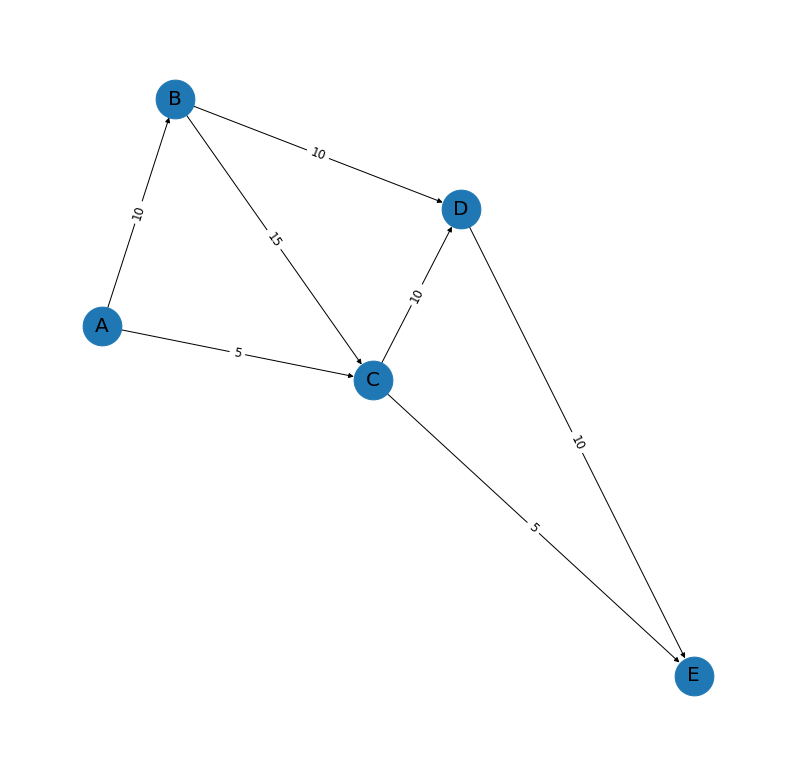

In [1]:
import networkx as nx
import matplotlib.pyplot as pp

# Criar o grafo dirigido
G = nx.DiGraph()

# Adicionar arestas e capacidades
edges = [
    ( 'A', 'B', 10 ),
    ( 'A', 'C', 5 ),
    ( 'B', 'C', 15 ),
    ( 'B', 'D', 10 ),
    ( 'C', 'D', 10 ),
    ( 'C', 'E', 5 ),
    ( 'D', 'E', 10 )
]

for u, v, capacity in edges:
    G.add_edge( u, v, capacity = capacity )

pos = nx.spring_layout( G, seed = 0 )

pp.figure( figsize = ( 14, 14 ) )

nx.draw_networkx_nodes( G, pos, node_size = 1500 )
nx.draw_networkx_edges( G, pos, node_size = 1500 )
nx.draw_networkx_labels( G, pos, font_size = 20, font_family = 'sans-serif' )

edge_labels = nx.get_edge_attributes( G, 'capacity' )
nx.draw_networkx_edge_labels( G, pos, edge_labels, font_size = 12, font_family = 'sans-serif' )

pp.margins( 0.1 )
pp.axis( 'off' )
pp.show()


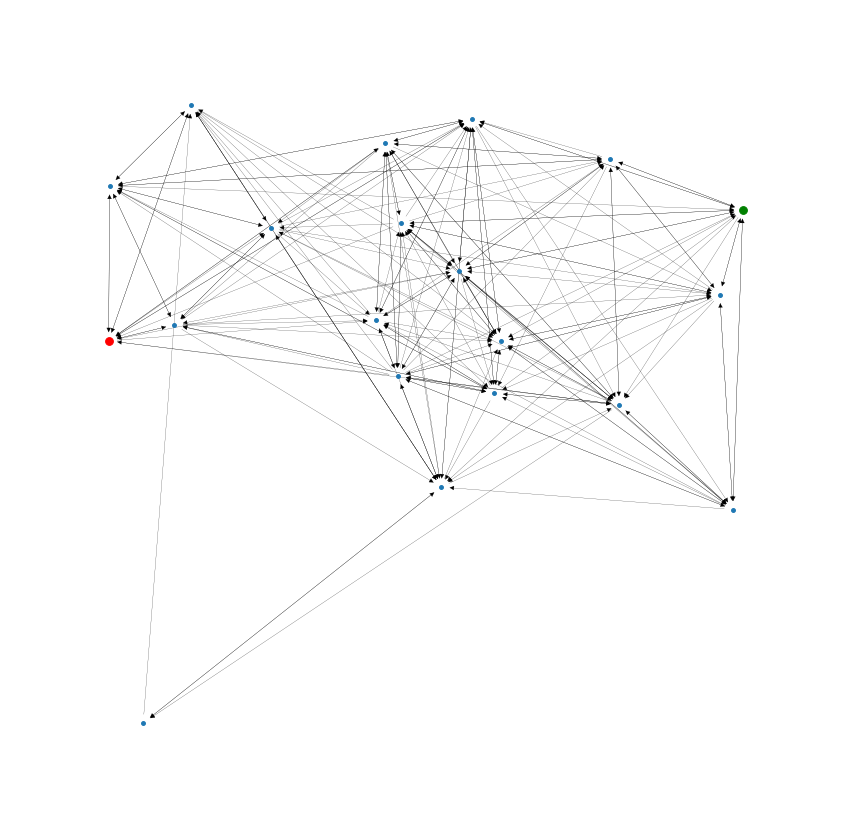

In [2]:
import networkx as nx
import matplotlib.pyplot as pp
import numpy as np

N = 20

# Gera N pontos aleatórios no quadrado [ 0, 1 ] x [ 0, 1 ]
np.random.seed( 0 )
pos = {}
for i in range( 1, N + 1 ):
    pos[ i ] = tuple( np.random.uniform( size = ( 2, ) ) )

# Conecta vértices com probabilidade proporcional à distância
G = nx.DiGraph()
for i in range( 1, N + 1 ):
    for j in range( 1, N + 1 ):
        d = (
            ( pos[ i ][ 0 ] - pos[ j ][ 0 ] ) ** 2 +
            ( pos[ i ][ 1 ] - pos[ j ][ 1 ] ) ** 2
        ) ** 0.5

        r = np.random.uniform()
        if ( i != j ) and ( d < r ):
            G.add_edge( i, j, capacity = 1 / d, weight = 1 )

# Origem é o mais à esquerda
mn_x = np.inf
o = 0
for i in G.nodes:
    if pos[ i ][ 0 ] < mn_x:
        mn_x = pos[ i ][ 0 ]
        o = i

# Destino é o mais à direita
mx_x = -np.inf
d = 0
for i in G.nodes:
    if pos[ i ][ 0 ] > mx_x:
        mx_x = pos[ i ][ 0 ]
        d = i

pp.figure( figsize = ( 15, 15 ) )

nx.draw_networkx_nodes( G, pos, node_size = 15 )
nx.draw_networkx_edges( G, pos, width = 0.2 )

pp.scatter( pos[ o ][ 0 ], pos[ o ][ 1 ], c = 'r', s = 60, zorder = 10 )
pp.scatter( pos[ d ][ 0 ], pos[ d ][ 1 ], c = 'g', s = 60, zorder = 10 )

pp.margins( 0.1 )
pp.axis( 'off' )
pp.show()


## 2. Solução Através do `NetworkX`

O pacote `NetworkX` possui uma função para resolver problemas de fluxo

<div style="text-align: center;">
 <iframe type="text/html" src="https://networkx.org/documentation/stable/reference/algorithms/flow.html" width="90%" height="700px" style="text-align: center; border: solid; border-radius: 10px;"> 
</div>

In [3]:
f_mx, f_dict = nx.maximum_flow( G, o, d )
print( f_mx )

26.817519692388025


55


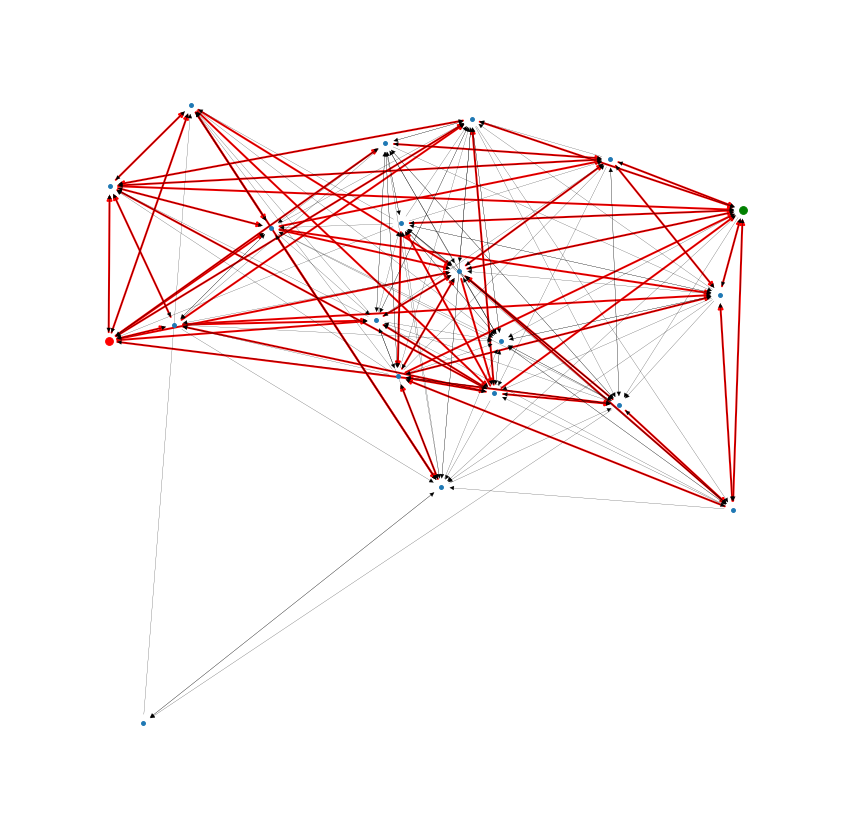

In [4]:
el = []
ld = {}
for i in f_dict.keys():
    for j in f_dict[ i ]:
        if f_dict[ i ][ j ] > 1e-6:
            el.append( ( i, j ) )
            ld[ ( i, j ) ] = '%.2f / %.2f' % ( f_dict[ i ][ j ], G.get_edge_data( i, j )[ 'capacity' ] )

print( len( el ) )

pp.figure( figsize = ( 15, 15 ) )

nx.draw_networkx_nodes( G, pos, node_size = 15 )
nx.draw_networkx_edges( G, pos, width = 2, edgelist = el, edge_color = 'r' )
nx.draw_networkx_edges( G, pos, width = 0.2 )

pp.scatter( pos[ o ][ 0 ], pos[ o ][ 1 ], c = 'r', s = 60, zorder = 10 )
pp.scatter( pos[ d ][ 0 ], pos[ d ][ 1 ], c = 'g', s = 60, zorder = 10 )

pp.margins( 0.1 )
pp.axis( 'off' )
pp.show()


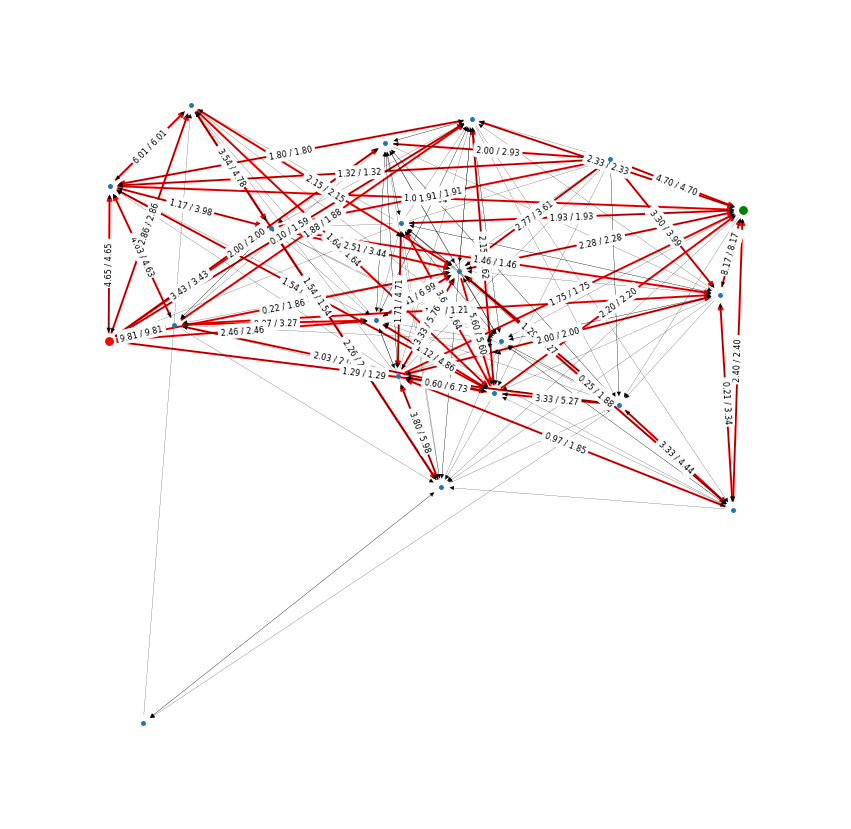

In [5]:
pp.figure( figsize = ( 15, 15 ) )

nx.draw_networkx_nodes( G, pos, node_size = 15 )
nx.draw_networkx_edges( G, pos, width = 2, edgelist = el, edge_color = 'r' )
nx.draw_networkx_edges( G, pos, width = 0.2 )
nx.draw_networkx_edge_labels( G, pos, ld, font_size = 8, font_family = 'sans-serif' )

pp.scatter( pos[ o ][ 0 ], pos[ o ][ 1 ], c = 'r', s = 60, zorder = 10 )
pp.scatter( pos[ d ][ 0 ], pos[ d ][ 1 ], c = 'g', s = 60, zorder = 10 )

pp.margins( 0.1 )
pp.axis( 'off' )
pp.show()


In [6]:
f_dict = nx.max_flow_min_cost( G, o, d )

41


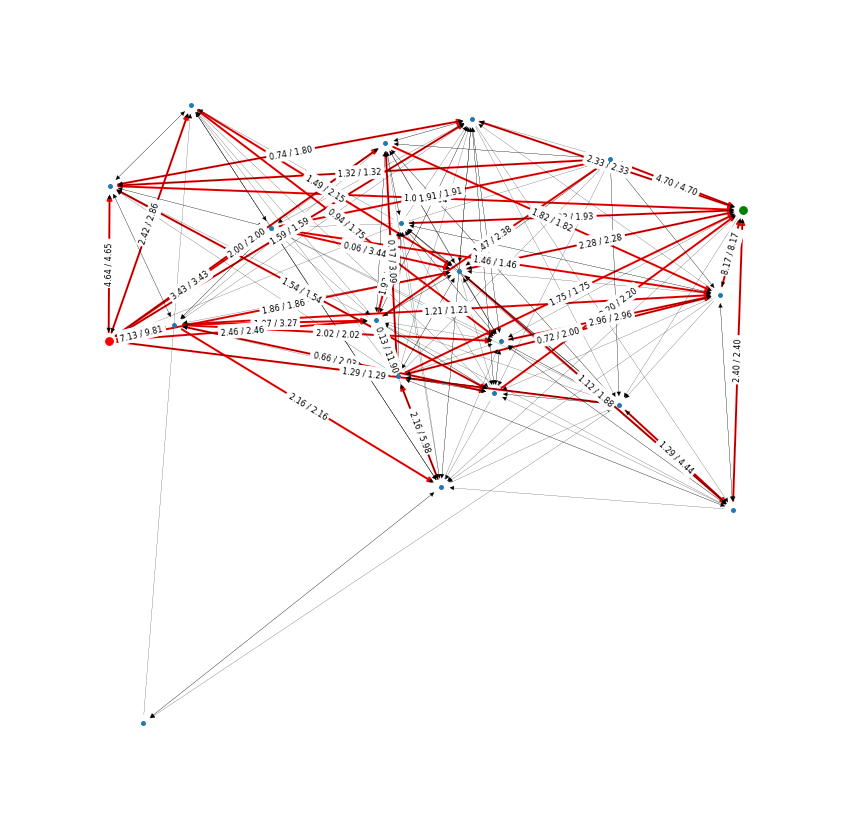

In [7]:
el = []
ld = {}
for i in f_dict.keys():
    for j in f_dict[ i ]:
        if f_dict[ i ][ j ] > 1e-6:
            el.append( ( i, j ) )
            ld[ ( i, j ) ] = '%.2f / %.2f' % ( f_dict[ i ][ j ], G.get_edge_data( i, j )[ 'capacity' ] )

print( len( el ) )

pp.figure( figsize = ( 15, 15 ) )

nx.draw_networkx_nodes( G, pos, node_size = 15 )
nx.draw_networkx_edges( G, pos, width = 2, edgelist = el, edge_color = 'r' )
nx.draw_networkx_edges( G, pos, width = 0.2 )
nx.draw_networkx_edge_labels( G, pos, ld, font_size = 8, font_family = 'sans-serif' )

pp.scatter( pos[ o ][ 0 ], pos[ o ][ 1 ], c = 'r', s = 60, zorder = 10 )
pp.scatter( pos[ d ][ 0 ], pos[ d ][ 1 ], c = 'g', s = 60, zorder = 10 )

pp.margins( 0.1 )
pp.axis( 'off' )
pp.show()


## 3. Solução Através de Otimização Linear

O problema do fluxo máximo pode ser modelado de forma simples como um problema de otimização linear

$$
\begin{align*}
        \max       & \quad F\\
        \text{s.a:}& \quad \sum_{( i, k ) \in E}x_{i, k} - \sum_{( k, j ) \in E}x_{k, j} = \begin{cases}F &\text{se } k = d\\ -F &\text{se } k = o\\ 0 & \text{caso contrário}\end{cases} &\quad \forall k \in V\\
                   & \quad 0 \le x_{i, j} \le f( i, j ) & \forall ( i, j ) \in E.
\end{align*}
$$


In [8]:
import mip

m = mip.Model()

# Uma variável por aresta
x = {}
for e in G.edges:
    x[ e ] = m.add_var( lb = 0.0, ub = G.get_edge_data( *e )[ 'capacity' ] )
# Fluxo
F = m.add_var( lb = 0.0 )

# Função objetivo
m.objective = -F

# Restrições:
for k in G.nodes:
    b = F if k == d else ( -F if k == o else 0 )
    m += (
        mip.xsum( x[ i, k ] for i in G.predecessors( k ) ) - \
            mip.xsum( x[ k, j ] for j in G.successors( k ) ) == \
                  b
    )

status = m.optimize()

Welcome to the CBC MILP Solver 
Version: Trunk
Build Date: Oct 24 2021 

Starting solution of the Linear programming problem using Dual Simplex

Coin0506I Presolve 20 (0) rows, 195 (0) columns and 390 (0) elements
Clp0014I Perturbing problem by 0.001% of 1 - largest nonzero change 4.2116734e-05 ( 0.0042116734%) - largest zero change 4.1778355e-05
Clp0000I Optimal - objective value -26.81752
Clp0032I Optimal objective -26.81751969 - 46 iterations time 0.002


In [9]:
print( status )

OptimizationStatus.OPTIMAL


43


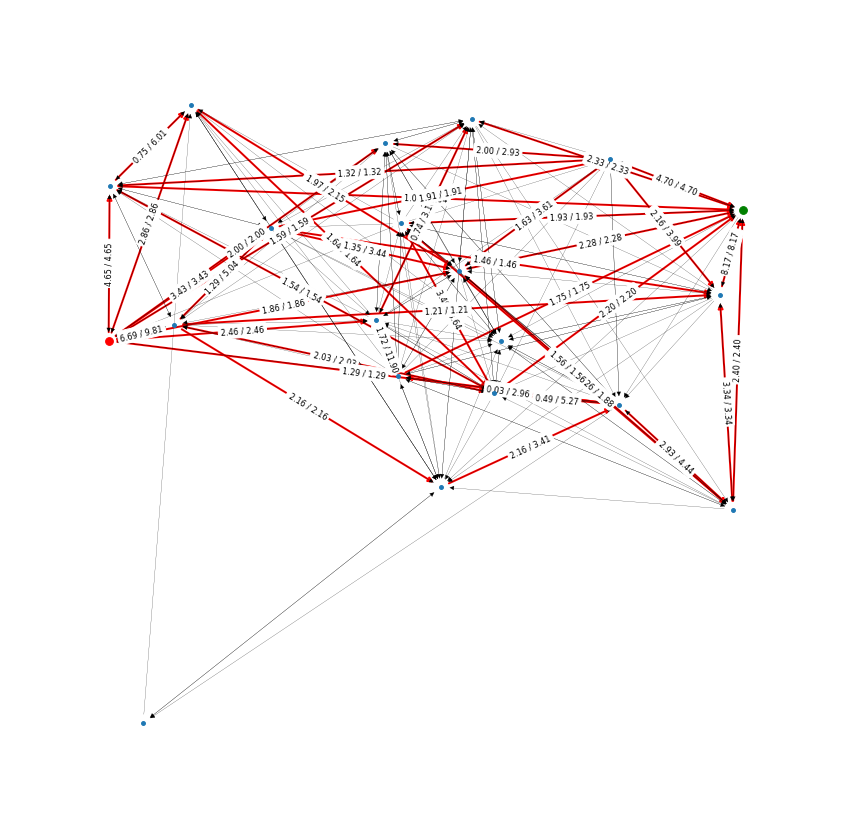

In [10]:
el = []
ld = {}
for e in G.edges:
    if x[ e ].x > 1e-6:
        el.append( e )
        ld[ e ] = '%.2f / %.2f' % ( x[ e ].x, G.get_edge_data( *e )[ 'capacity' ] )

print( len( el ) )

pp.figure( figsize = ( 15, 15 ) )

nx.draw_networkx_nodes( G, pos, node_size = 15 )
nx.draw_networkx_edges( G, pos, width = 2, edgelist = el, edge_color = 'r' )
nx.draw_networkx_edges( G, pos, width = 0.2 )
nx.draw_networkx_edge_labels( G, pos, ld, font_size = 8, font_family = 'sans-serif' )

pp.scatter( pos[ o ][ 0 ], pos[ o ][ 1 ], c = 'r', s = 60, zorder = 10 )
pp.scatter( pos[ d ][ 0 ], pos[ d ][ 1 ], c = 'g', s = 60, zorder = 10 )

pp.margins( 0.1 )
pp.axis( 'off' )
pp.show()
